In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df['species']=iris.target
df['species_name']=df['species'].map({0:'setosa',1:'versicolor',2:'vriginica'})

print(df.shape)
print(df.head())
print(df['species_name'].value_counts())

(150, 6)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  
species_name
setosa        50
versicolor    50
vriginica     50
Name: count, dtype: int64


In [4]:
from sklearn.preprocessing import StandardScaler
x,y=iris.data,iris.target
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)


In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x_scaled,y,random_state=42,test_size=0.2,stratify=y
)


In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

for k in range(1,21):
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train,y_train)
    acc=accuracy_score(y_test,model.predict(x_test))
    print(k,round(acc,3))

1 0.967
2 0.933
3 0.933
4 0.933
5 0.933
6 0.933
7 0.967
8 0.933
9 0.967
10 0.967
11 0.967
12 0.967
13 0.967
14 0.933
15 0.933
16 0.933
17 0.967
18 0.967
19 0.967
20 0.933


In [13]:
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)
predictions=model.predict(x_test)

In [16]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
print("Accuracy :",accuracy_score(y_test,predictions))
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions,target_names=iris.target_names))


Accuracy : 0.9333333333333333
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [18]:
sample=[[5.9,3.0,5.1,1.8]]
sample_scaled=scaler.transform(sample)
pred=model.predict(sample_scaled)
print(iris.target_names[pred[0]])


virginica


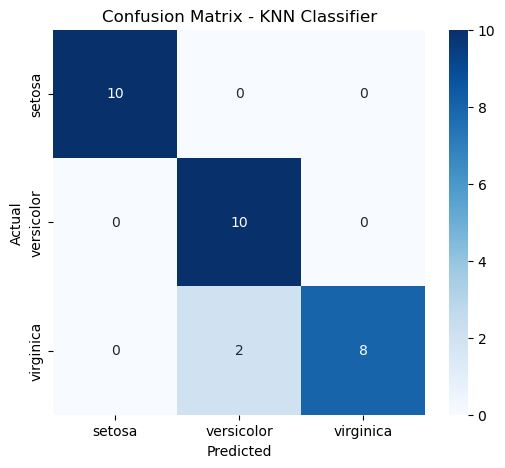

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=iris.target_names,yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN Classifier")
plt.show()

C:\Users\manas\AppData\Local\Temp\ipykernel_10252\2299342379.py:19: UserWarning: The following kwargs were not used by contour: 'aplha'
  plt.contourf(xx,yy,Z,aplha=0.3,cmap='viridis')


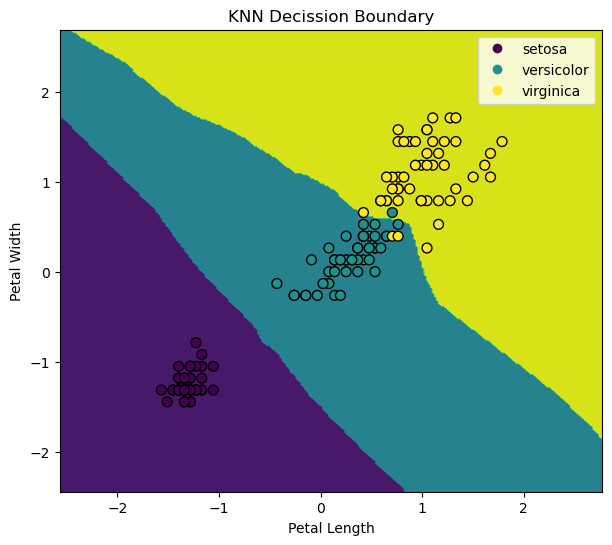

In [25]:
import numpy as np
x_2d=x_scaled[:,2:4]
x_train_2d,x_test_2d,y_train_2d,y_test_2d=train_test_split(
    x_2d,y,random_state=42,stratify=y,test_size=0.2
)

model_2d=KNeighborsClassifier(n_neighbors=5)
model_2d.fit(x_train_2d,y_train_2d)

x_min, x_max = x_2d[:, 0].min() - 1, x_2d[:, 0].max() + 1
y_min, y_max = x_2d[:, 1].min() - 1, x_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                      np.arange(y_min, y_max, 0.02))

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contourf(xx,yy,Z,aplha=0.3,cmap='viridis')
scatter=plt.scatter(x_2d[:,0],x_2d[:,1],c=y,cmap='viridis',edgecolor='k',s=50)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("KNN Decission Boundary")
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names))
plt.show()

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model=LogisticRegression(max_iter=200)
log_model.fit(x_train,y_train)
log_pred=log_model.predict(x_test)

log_acc=accuracy_score(y_test,log_pred)
print("Logistic Regression: ",round(log_acc,3))



Logistic Regression:  0.933


In [28]:
from sklearn.tree import DecisionTreeClassifier
tree_model=DecisionTreeClassifier(random_state=42)
tree_model.fit(x_train,y_train)
tree_pred=tree_model.predict(x_test)

tree_acc=accuracy_score(y_test,tree_pred)
print("Decision Tree Classifier:",tree_acc)


Decision Tree Classifier: 0.9333333333333333


In [29]:
knn_acc=accuracy_score(y_test,predictions)

print(f"{'Model':<20}{'Accuracy'}")
print(f"{'KNN' :<20}{knn_acc:.3f}")
print(f"{"Logistic Regression":<20}{log_acc:.3f}")
print(f"{"Desicion Tree Classifier" :.20}{tree_acc:.3f}")




Model               Accuracy
KNN                 0.933
Logistic Regression 0.933
Desicion Tree Classi0.933


In [30]:
from sklearn.model_selection import cross_val_score
knn_cv_scores=cross_val_score(KNeighborsClassifier(n_neighbors=5),x_scaled,y,cv=5)
print("Cross-validation scores for each fold:", knn_cv_scores.round(3))
print("Mean accuracy:", round(knn_cv_scores.mean(), 3))
print("Standard deviation:", round(knn_cv_scores.std(), 3))

Cross-validation scores for each fold: [0.967 0.967 0.933 0.933 1.   ]
Mean accuracy: 0.96
Standard deviation: 0.025


In [32]:
log_cv_scores = cross_val_score(LogisticRegression(max_iter=200), x_scaled, y, cv=5)
tree_cv_scores = cross_val_score(DecisionTreeClassifier(random_state=42), x_scaled, y, cv=5)

print(f"{'Model':<20}{'Mean Accuracy':<16}{'Std Dev'}")
print(f"{'KNN (K=5)':<20}{knn_cv_scores.mean():<16.3f}{knn_cv_scores.std():.3f}")
print(f"{'Logistic Regression':<20}{log_cv_scores.mean():<16.3f}{log_cv_scores.std():.3f}")
print(f"{'Decision Tree':<20}{tree_cv_scores.mean():<16.3f}{tree_cv_scores.std():.3f}")

Model               Mean Accuracy   Std Dev
KNN (K=5)           0.960           0.025
Logistic Regression 0.960           0.039
Decision Tree       0.953           0.034
